In [ ]:
!pip install -q transformers accelerate bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 11.5 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import login

login()

In [ ]:
from huggingface_hub import whoami

info = whoami()
print("Logged-in Hugging Face account:", info["name"])

In [ ]:
from huggingface_hub import get_token

token = get_token()
print("Token available:", token is not None)

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")
else:
    print("WARNING: GPU not detected!")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [ ]:
from transformers import AutoConfig

print("✅ AutoConfig imported!")

In [ ]:
from transformers import AutoTokenizer

model_name = "meta-llama/Llama-3.1-8B"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("✅ Hugging Face access works!")
print("Tokenizer loaded successfully.")

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

✅ Hugging Face access works!
Tokenizer loaded successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving negation_stimuli.csv to negation_stimuli.csv
Saving polysemy_stimuli.csv to polysemy_stimuli.csv


In [ ]:
import pandas as pd

polysemy_df = pd.read_csv("polysemy_stimuli.csv")
negation_df = pd.read_csv("negation_stimuli.csv")

print("Polysemy dataset:", polysemy_df.shape)
print("Negation dataset:", negation_df.shape)

display(polysemy_df.head())
display(negation_df.head())

Polysemy dataset: (180, 5)
Negation dataset: (50, 4)


,word,sense,dominance,context_level,sentence
0,yard,outdoor_area,dominant,1,yard
1,yard,outdoor_area,dominant,2,The kids are playing in the yard.
2,yard,outdoor_area,dominant,2,Her yard is full of flowers.
3,yard,outdoor_area,dominant,2,He mowed the yard yesterday.
4,yard,outdoor_area,dominant,2,We built a fence around the yard.


,pair_id,category,polarity,sentence
0,1,taxonomic,affirmative,Birds can fly.
1,1,taxonomic,negated,Birds cannot fly.
2,2,taxonomic,affirmative,Whales are mammals.
3,2,taxonomic,negated,Whales are not mammals.
4,3,taxonomic,affirmative,Spiders have eight legs.


In [ ]:
#Google Drive Set Up
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/AT1_Term_Paper"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/embeddings", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/results", exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("✅ Google Drive setup complete!")

Project folder: /content/drive/MyDrive/AT1_Term_Paper
✅ Google Drive setup complete!


In [ ]:
MODEL_NAME = "meta-llama/Llama-3.1-8B"

print("Model:", MODEL_NAME)

Model: meta-llama/Llama-3.1-8B


In [ ]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    token=token,
    quantization_config=quant_config,
    device_map="auto",
    output_hidden_states=True
)

base_model.eval()

print("✅ Llama 3.1 8B Base loaded!")
print("Number of layers:", base_model.config.num_hidden_layers)
print("Hidden size:", base_model.config.hidden_size)

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

✅ Llama 3.1 8B Base loaded!
Number of layers: 32
Hidden size: 4096


In [ ]:
import re

def find_target_token_indices(sentence, target_word, tokenizer):
    """
    Find the token indices corresponding to the target word.

    Allows simple plural forms, e.g.:
        yard -> yards
        tank -> tanks

    Uses character offsets to identify the exact target span.
    """

    # Allow singular target or simple plural form
    target_pattern = (
        r'\b' +
        re.escape(target_word) +
        r'(?:s)?' +
        r'\b'
    )

    matches = list(
        re.finditer(
            target_pattern,
            sentence,
            flags=re.IGNORECASE
        )
    )

    if len(matches) == 0:
        raise ValueError(
            f"Target word '{target_word}' not found in sentence:\n{sentence}"
        )

    if len(matches) > 1:
        raise ValueError(
            f"Target word '{target_word}' occurs multiple times "
            f"in sentence:\n{sentence}"
        )

    match = matches[0]

    word_start = match.start()
    word_end = match.end()

    # Tokenize with character offsets
    encoding = tokenizer(
        sentence,
        return_offsets_mapping=True,
        add_special_tokens=True,
        return_tensors="pt"
    )

    offsets = encoding["offset_mapping"][0].tolist()

    target_indices = []

    for i, (start, end) in enumerate(offsets):

        # Ignore special tokens
        if start == 0 and end == 0:
            continue

        # Token overlaps target span
        if start < word_end and end > word_start:
            target_indices.append(i)

    if len(target_indices) == 0:
        raise ValueError(
            f"No tokens found for target word '{target_word}' "
            f"in sentence:\n{sentence}"
        )

    return target_indices, encoding

In [ ]:
from transformers import AutoTokenizer

base_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    token=token
)

print("✅ Base tokenizer loaded!")

✅ Base tokenizer loaded!


In [ ]:
test_row = polysemy_df.iloc[0]

target_indices, encoding = find_target_token_indices(
    test_row["sentence"],
    test_row["word"],
    base_tokenizer
)

print("Sentence:", test_row["sentence"])
print("Target word:", test_row["word"])
print("Target token indices:", target_indices)

print("\nAll tokens:")
for i, token_id in enumerate(encoding["input_ids"]):
    token = base_tokenizer.decode([token_id])
    print(i, token_id, repr(token))

Sentence: yard
Target word: yard
Target token indices: [1]

All tokens:
0 tensor([128000,  17884]) ['<|begin_of_text|>yard']


In [ ]:
# Find the first Level 3 example
level3_row = polysemy_df[polysemy_df["context_level"] == 3].iloc[0]

print("Word:", level3_row["word"])
print("Sense:", level3_row["sense"])
print("Context level:", level3_row["context_level"])
print("Sentence:", level3_row["sentence"])

Word: yard
Sense: outdoor_area
Context level: 3
Sentence: Every Saturday morning my father spends hours raking leaves in the yard behind our house.


In [ ]:
TARGET_LAYERS = list(range(4, 33, 4))

print("Target layers:", TARGET_LAYERS)

Target layers: [4, 8, 12, 16, 20, 24, 28, 32]


In [ ]:
import torch
import numpy as np

def extract_target_embeddings(
    sentence,
    target_word,
    model,
    tokenizer,
    target_layers=TARGET_LAYERS
):
    """
    Extract target-word hidden representations from selected Llama layers.

    For multi-token target words, hidden states are mean-pooled
    across the target tokens.

    Returns:
        embeddings: dictionary
            layer number -> 4096-dimensional numpy vector
        target_indices: token positions of the target word
    """

    # --------------------------------------------------
    # 1. Find target token(s)
    # --------------------------------------------------
    target_indices, encoding = find_target_token_indices(
        sentence,
        target_word,
        tokenizer
    )

    # --------------------------------------------------
    # 2. Move inputs to the same device as the model
    # --------------------------------------------------
    device = next(model.parameters()).device

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    # --------------------------------------------------
    # 3. Forward pass
    # --------------------------------------------------
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )

    # --------------------------------------------------
    # 4. Extract target representation from each layer
    # --------------------------------------------------
    embeddings = {}

    for layer in target_layers:

        # hidden_states[0] = input embedding
        # hidden_states[1] = transformer layer 1
        # ...
        # hidden_states[32] = transformer layer 32

        layer_hidden = outputs.hidden_states[layer]

        # Select target token(s)
        target_hidden = layer_hidden[
            0,
            target_indices,
            :
        ]

        # Mean-pool if target has multiple tokens
        target_embedding = target_hidden.mean(dim=0)

        # Move to CPU and convert to numpy
        embeddings[layer] = (
            target_embedding
            .detach()
            .cpu()
            .float()
            .numpy()
        )

    return embeddings, target_indices

In [ ]:
import pandas as pd
import numpy as np
import os
import pickle
from tqdm.auto import tqdm

# --------------------------------------------------
# Output file
# --------------------------------------------------

BASE_OUTPUT_FILE = f"{PROJECT_DIR}/embeddings/base_embeddings.pkl"


# --------------------------------------------------
# Main dataset extraction function
# --------------------------------------------------

def extract_dataset_embeddings(
    df,
    model,
    tokenizer,
    model_name="base"
):
    """
    Extract target-word embeddings for every row in the dataset.

    Each row keeps:
        - dataset row index
        - word
        - sense
        - dominance
        - context level
        - sentence
        - model
        - target token indices
        - embeddings for layers 4, 8, ..., 32
    """

    results = []

    for row_idx, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc=f"Extracting {model_name} embeddings"
    ):

        try:

            # Extract target-word representations
            embeddings, target_indices = extract_target_embeddings(
                sentence=row["sentence"],
                target_word=row["word"],
                model=model,
                tokenizer=tokenizer
            )

            # Store metadata + embeddings
            result = {
                "row_id": row_idx,
                "word": row["word"],
                "sense": row["sense"],
                "dominance": row["dominance"],
                "context_level": row["context_level"],
                "sentence": row["sentence"],
                "model": model_name,
                "target_token_indices": target_indices,
                "embeddings": embeddings
            }

            results.append(result)

        except Exception as e:

            print(
                f"\n⚠️ Error at row {row_idx}: "
                f"{row['word']} | {row['sentence']}"
            )

            print("Error:", e)

    return results

In [ ]:
base_results = extract_dataset_embeddings(
    df=polysemy_df,
    model=base_model,
    tokenizer=base_tokenizer,
    model_name="base"
)

print("\n✅ Extraction complete!")
print("Number of successful rows:", len(base_results))

Extracting base embeddings:   0%|          | 0/180 [00:00<?, ?it/s]


✅ Extraction complete!
Number of successful rows: 180


In [ ]:
import pickle
import os

BASE_OUTPUT_FILE = f"{PROJECT_DIR}/embeddings/base_embeddings.pkl"

with open(BASE_OUTPUT_FILE, "wb") as f:
    pickle.dump(base_results, f)

print("✅ Base embeddings saved!")
print("File:", BASE_OUTPUT_FILE)
print("File exists:", os.path.exists(BASE_OUTPUT_FILE))

✅ Base embeddings saved!
File: /content/drive/MyDrive/AT1_Term_Paper/embeddings/base_embeddings.pkl
File exists: True


Llama 3.1 8B Instruct

In [ ]:
INSTRUCT_MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

print("Model:", INSTRUCT_MODEL_NAME)

Model: meta-llama/Llama-3.1-8B-Instruct


In [ ]:
from huggingface_hub import hf_hub_download

index_file = hf_hub_download(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    filename="model.safetensors.index.json"
)

print("✅ Instruct index downloaded!")
print("Path:", index_file)

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

✅ Instruct index downloaded!
Path: /root/.cache/huggingface/hub/models--meta-llama--Llama-3.1-8B-Instruct/snapshots/0e9e39f249a16976918f6564b8830bc894c89659/model.safetensors.index.json


In [ ]:
from transformers import AutoTokenizer

instruct_tokenizer = AutoTokenizer.from_pretrained(
    INSTRUCT_MODEL_NAME,
    token=token
)

print("✅ Instruct tokenizer loaded!")

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

✅ Instruct tokenizer loaded!


In [ ]:
from transformers import AutoModelForCausalLM

# Load config explicitly
instruct_config = AutoConfig.from_pretrained(
    INSTRUCT_MODEL_NAME,
    token=token
)

# Enable hidden states through the config
instruct_config.output_hidden_states = True

print("Config ready:")
print("Model type:", instruct_config.model_type)
print("Layers:", instruct_config.num_hidden_layers)
print("Hidden size:", instruct_config.hidden_size)

# Load model
instruct_model = AutoModelForCausalLM.from_pretrained(
    INSTRUCT_MODEL_NAME,
    config=instruct_config,
    token=token,
    quantization_config=quant_config,
    device_map="auto"
)

instruct_model.eval()

print("\n✅ Llama 3.1 8B Instruct loaded!")
print("Number of layers:", instruct_model.config.num_hidden_layers)
print("Hidden size:", instruct_model.config.hidden_size)

Config ready:
Model type: llama
Layers: 32
Hidden size: 4096


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]


✅ Llama 3.1 8B Instruct loaded!
Number of layers: 32
Hidden size: 4096


In [ ]:
from tqdm.auto import tqdm
import pickle

instruct_embeddings = {}
instruct_errors = []

print("Starting Instruct embedding extraction...")

for idx, row in tqdm(
    polysemy_df.iterrows(),
    total=len(polysemy_df),
    desc="Extracting instruct embeddings"
):

    try:
        embeddings, target_indices = extract_target_embeddings(
            sentence=row["sentence"],
            target_word=row["word"],
            model=instruct_model,
            tokenizer=instruct_tokenizer
        )

        instruct_embeddings[idx] = {
            "row_id": row.get("row_id", idx),
            "word": row["word"],
            "sense": row["sense"],
            "context_level": row["context_level"],
            "sentence": row["sentence"],
            "target_indices": target_indices,
            "embeddings": embeddings
        }

    except Exception as e:
        instruct_errors.append({
            "index": idx,
            "word": row["word"],
            "sense": row["sense"],
            "context_level": row["context_level"],
            "sentence": row["sentence"],
            "error": str(e)
        })

print("\n✅ Instruct extraction complete!")
print("Successful rows:", len(instruct_embeddings))
print("Failed rows:", len(instruct_errors))

Starting Instruct embedding extraction...


Extracting instruct embeddings:   0%|          | 0/180 [00:00<?, ?it/s]


✅ Instruct extraction complete!
Successful rows: 180
Failed rows: 0


In [ ]:
import os
import pickle

# Save Instruct embeddings
instruct_path = "/content/instruct_embeddings.pkl"

with open(instruct_path, "wb") as f:
    pickle.dump(instruct_embeddings, f)

print("✅ Instruct embeddings saved!")
print("File:", instruct_path)
print(
    "Size:",
    round(os.path.getsize(instruct_path) / (1024**2), 2),
    "MB"
)

✅ Instruct embeddings saved!
File: /content/instruct_embeddings.pkl
Size: 22.57 MB


In [ ]:
import pickle

base_embeddings_path = (
    "/content/drive/MyDrive/AT1_Term_Paper/embeddings/base_embeddings.pkl"
)

with open(base_embeddings_path, "rb") as f:
    base_embeddings = pickle.load(f)

print("✅ Base embeddings loaded!")
print("Number of rows:", len(base_embeddings))

✅ Base embeddings loaded!
Number of rows: 180


In [ ]:
print("Base rows:", len(base_embeddings))
print("Instruct rows:", len(instruct_embeddings))

# Compare metadata
base_keys = [
    (
        item["word"],
        item["sense"],
        item["context_level"],
        item["sentence"]
    )
    for item in base_embeddings
]

instruct_keys = [
    (
        item["word"],
        item["sense"],
        item["context_level"],
        item["sentence"]
    )
    for item in instruct_embeddings.values()
]

print("\nMetadata identical:", base_keys == instruct_keys)

# Check one example
first_base = next(iter(base_embeddings))
first_instruct = next(iter(instruct_embeddings.values()))

print("\nExample:")
print("Word:", first_base["word"])
print("Sense:", first_base["sense"])
print("Context level:", first_base["context_level"])

print("\nBase layers:", list(first_base["embeddings"].keys()))
print("Instruct layers:", list(first_instruct["embeddings"].keys()))

print("\nBase embedding shape:",
      next(iter(first_base["embeddings"].values())).shape)

print("Instruct embedding shape:",
      next(iter(first_instruct["embeddings"].values())).shape)

Base rows: 180
Instruct rows: 180

Metadata identical: True

Example:
Word: yard
Sense: outdoor_area
Context level: 1

Base layers: [4, 8, 12, 16, 20, 24, 28, 32]
Instruct layers: [4, 8, 12, 16, 20, 24, 28, 32]

Base embedding shape: (4096,)
Instruct embedding shape: (4096,)


In [ ]:
import torch
import pandas as pd
import numpy as np

def cosine_similarity_safe(vec1, vec2):
    vec1 = torch.as_tensor(vec1, dtype=torch.float32)
    vec2 = torch.as_tensor(vec2, dtype=torch.float32)

    similarity = torch.nn.functional.cosine_similarity(
        vec1.unsqueeze(0),
        vec2.unsqueeze(0)
    ).item()

    # Protect against tiny floating-point errors such as 1.0000017
    return float(np.clip(similarity, -1.0, 1.0))


def calculate_sense_similarity(embeddings_dict, dataset):

    results = []

    for word in dataset["word"].unique():

        word_data = dataset[dataset["word"] == word]

        for context_level in sorted(word_data["context_level"].unique()):

            level_data = word_data[
                word_data["context_level"] == context_level
            ]

            # We expect exactly two senses
            senses = level_data["sense"].unique()

            if len(senses) != 2:
                print(
                    f"⚠️ Skipping {word}, level {context_level}: "
                    f"found {len(senses)} senses"
                )
                continue

            sense1, sense2 = senses

            # Find the corresponding embedding entries
            rows1 = level_data[level_data["sense"] == sense1]
            rows2 = level_data[level_data["sense"] == sense2]

            # Compare every sentence variant of sense 1
            # against every sentence variant of sense 2
            for layer in TARGET_LAYERS:

                similarities = []

                for idx1 in rows1.index:
                    for idx2 in rows2.index:

                        emb1 = embeddings_dict[idx1]["embeddings"][layer]
                        emb2 = embeddings_dict[idx2]["embeddings"][layer]

                        sim = cosine_similarity_safe(emb1, emb2)
                        similarities.append(sim)

                results.append({
                    "word": word,
                    "context_level": context_level,
                    "layer": layer,
                    "sense1": sense1,
                    "sense2": sense2,
                    "cosine_similarity_mean": np.mean(similarities),
                    "cosine_similarity_std": np.std(similarities),
                    "n_comparisons": len(similarities)
                })

    return pd.DataFrame(results)

In [ ]:
import os
import pickle

# Create analysis/output directory in Google Drive
ANALYSIS_DIR = f"{PROJECT_DIR}/embeddings"

os.makedirs(ANALYSIS_DIR, exist_ok=True)

# --------------------------------------------------
# Load Base embeddings
# --------------------------------------------------

base_embeddings_path = f"{ANALYSIS_DIR}/base_embeddings.pkl"

with open(base_embeddings_path, "rb") as f:
    base_embeddings = pickle.load(f)

print("✅ Base embeddings loaded:", len(base_embeddings))


# --------------------------------------------------
# Load Instruct embeddings
# --------------------------------------------------

instruct_embeddings_path = "/content/instruct_embeddings.pkl"

with open(instruct_embeddings_path, "rb") as f:
    instruct_embeddings = pickle.load(f)

print("✅ Instruct embeddings loaded:", len(instruct_embeddings))


# --------------------------------------------------
# Save Instruct embeddings permanently to Drive
# --------------------------------------------------

instruct_drive_path = f"{ANALYSIS_DIR}/instruct_embeddings.pkl"

with open(instruct_drive_path, "wb") as f:
    pickle.dump(instruct_embeddings, f)

print("✅ Instruct embeddings saved to Drive!")
print("Location:", instruct_drive_path)


# --------------------------------------------------
# Final verification
# --------------------------------------------------

print("\n--- FINAL CHECK ---")
print("Base:", len(base_embeddings))
print("Instruct:", len(instruct_embeddings))

print("\nBase example:")
print(base_embeddings[0]["word"],
      base_embeddings[0]["sense"],
      base_embeddings[0]["context_level"])

print("\nInstruct example:")
print(instruct_embeddings[0]["word"],
      instruct_embeddings[0]["sense"],
      instruct_embeddings[0]["context_level"])

✅ Base embeddings loaded: 180
✅ Instruct embeddings loaded: 180
✅ Instruct embeddings saved to Drive!
Location: /content/drive/MyDrive/AT1_Term_Paper/embeddings/instruct_embeddings.pkl

--- FINAL CHECK ---
Base: 180
Instruct: 180

Base example:
yard outdoor_area 1

Instruct example:
yard outdoor_area 1


In [ ]:
import pandas as pd
import numpy as np

TARGET_LAYERS = [4, 8, 12, 16, 20, 24, 28, 32]


def build_embedding_dataframe(
    base_embeddings,
    instruct_embeddings,
    dataset
):
    rows = []

    # ----------------------------------------
    # BASE
    # ----------------------------------------
    for item in base_embeddings:

        row_id = int(item["row_id"])

        # Get metadata directly from original dataset
        original = dataset.loc[row_id]

        for layer in TARGET_LAYERS:

            rows.append({
                "row_id": row_id,
                "word": original["word"],
                "sense": original["sense"],
                "dominance": original["dominance"],
                "context_level": int(original["context_level"]),
                "sentence": original["sentence"],
                "model": "base",
                "layer": layer,
                "embedding": np.asarray(
                    item["embeddings"][layer],
                    dtype=np.float32
                ).reshape(-1)
            })

    # ----------------------------------------
    # INSTRUCT
    # ----------------------------------------
    instruct_items = (
        instruct_embeddings.values()
        if isinstance(instruct_embeddings, dict)
        else instruct_embeddings
    )

    for item in instruct_items:

        row_id = int(item["row_id"])

        original = dataset.loc[row_id]

        for layer in TARGET_LAYERS:

            rows.append({
                "row_id": row_id,
                "word": original["word"],
                "sense": original["sense"],
                "dominance": original["dominance"],
                "context_level": int(original["context_level"]),
                "sentence": original["sentence"],
                "model": "instruct",
                "layer": layer,
                "embedding": np.asarray(
                    item["embeddings"][layer],
                    dtype=np.float32
                ).reshape(-1)
            })

    return pd.DataFrame(rows)


all_embeddings = build_embedding_dataframe(
    base_embeddings,
    instruct_embeddings,
    polysemy_df
)

print("✅ Master embedding DataFrame created!")
print("Shape:", all_embeddings.shape)

display(all_embeddings.head())

✅ Master embedding DataFrame created!
Shape: (2880, 9)


,row_id,word,sense,dominance,context_level,sentence,model,layer,embedding
0,0,yard,outdoor_area,dominant,1,yard,base,4,"[-0.010498047, 0.033447266, 0.03173828, 0.0192..."
1,0,yard,outdoor_area,dominant,1,yard,base,8,"[0.14746094, 0.047851562, -0.05859375, 0.08984..."
2,0,yard,outdoor_area,dominant,1,yard,base,12,"[-0.06542969, 0.091308594, 0.0043945312, -0.08..."
3,0,yard,outdoor_area,dominant,1,yard,base,16,"[0.018188477, -0.009277344, 0.10449219, -0.138..."
4,0,yard,outdoor_area,dominant,1,yard,base,20,"[0.03515625, -0.33789062, 0.16113281, -0.16796..."


In [ ]:
print("Total rows:", len(all_embeddings))

print("\nRows per model:")
print(all_embeddings["model"].value_counts())

print("\nRows per layer:")
print(all_embeddings["layer"].value_counts().sort_index())

print("\nUnique words:", all_embeddings["word"].nunique())
print("Words:", sorted(all_embeddings["word"].unique()))

print("\nContext levels:")
print(all_embeddings["context_level"].value_counts().sort_index())

print("\nEmbedding dimensions:")
print(
    all_embeddings["embedding"]
    .apply(lambda x: x.shape)
    .value_counts()
)

Total rows: 2880

Rows per model:
model
base        1440
instruct    1440
Name: count, dtype: int64

Rows per layer:
layer
4     360
8     360
12    360
16    360
20    360
24    360
28    360
32    360
Name: count, dtype: int64

Unique words: 10
Words: ['band', 'chest', 'racket', 'seal', 'staple', 'tank', 'temple', 'tissue', 'trunk', 'yard']

Context levels:
context_level
1     320
2    1280
3    1280
Name: count, dtype: int64

Embedding dimensions:
embedding
(4096,)    2880
Name: count, dtype: int64


In [ ]:
from sklearn.metrics.pairwise import cosine_distances
from itertools import combinations


def calculate_distance_gap(df):

    results = []

    groups = df.groupby(
        ["model", "word", "context_level", "layer"]
    )

    for (model, word, context_level, layer), subset in groups:

        senses = list(subset["sense"].unique())

        if len(senses) != 2:
            continue

        same_distances = []
        different_distances = []

        # ========================================
        # SAME-SENSE DISTANCES
        # ========================================

        for sense in senses:

            vectors = np.vstack(
                subset[
                    subset["sense"] == sense
                ]["embedding"].values
            )

            # Need at least two examples
            if len(vectors) >= 2:

                distance_matrix = cosine_distances(vectors)

                upper_triangle = distance_matrix[
                    np.triu_indices(
                        len(vectors),
                        k=1
                    )
                ]

                same_distances.extend(
                    upper_triangle.tolist()
                )

        # ========================================
        # DIFFERENT-SENSE DISTANCES
        # ========================================

        sense1_vectors = np.vstack(
            subset[
                subset["sense"] == senses[0]
            ]["embedding"].values
        )

        sense2_vectors = np.vstack(
            subset[
                subset["sense"] == senses[1]
            ]["embedding"].values
        )

        cross_distances = cosine_distances(
            sense1_vectors,
            sense2_vectors
        ).flatten()

        different_distances.extend(
            cross_distances.tolist()
        )

        # ========================================
        # STORE RESULT
        # ========================================

        same_mean = (
            np.mean(same_distances)
            if len(same_distances) > 0
            else np.nan
        )

        diff_mean = np.mean(different_distances)

        gap = (
            diff_mean - same_mean
            if not np.isnan(same_mean)
            else np.nan
        )

        results.append({
            "model": model,
            "word": word,
            "context_level": context_level,
            "layer": layer,
            "same_sense_distance": same_mean,
            "different_sense_distance": diff_mean,
            "distance_gap": gap
        })

    return pd.DataFrame(results)


gap_df = calculate_distance_gap(all_embeddings)

print("✅ Distance-gap analysis complete!")
print("Shape:", gap_df.shape)

display(gap_df.head(12))

✅ Distance-gap analysis complete!
Shape: (480, 7)


,model,word,context_level,layer,same_sense_distance,different_sense_distance,distance_gap
0,base,band,1,4,NaN,0.000000,NaN
1,base,band,1,8,NaN,0.000000,NaN
2,base,band,1,12,NaN,0.000000,NaN
3,base,band,1,16,NaN,0.000000,NaN
4,base,band,1,20,NaN,0.000000,NaN
5,base,band,1,24,NaN,0.000000,NaN
6,base,band,1,28,NaN,0.000000,NaN
7,base,band,1,32,NaN,0.000000,NaN
8,base,band,2,4,0.343539,0.397066,0.053527
9,base,band,2,8,0.382593,0.480123,0.097531


In [ ]:
summary_gap = (
    gap_df
    .groupby(["model", "context_level", "layer"])
    [["same_sense_distance",
      "different_sense_distance",
      "distance_gap"]]
    .mean()
    .reset_index()
)

display(summary_gap.head(20))

,model,context_level,layer,same_sense_distance,different_sense_distance,distance_gap
0,base,1,4,NaN,0.000000,NaN
1,base,1,8,NaN,0.000000,NaN
2,base,1,12,NaN,0.000000,NaN
3,base,1,16,NaN,0.000000,NaN
4,base,1,20,NaN,0.000000,NaN
5,base,1,24,NaN,0.000000,NaN
6,base,1,28,NaN,0.000000,NaN
7,base,1,32,NaN,0.000000,NaN
8,base,2,4,0.287812,0.412514,0.124702
9,base,2,8,0.373970,0.573017,0.199047


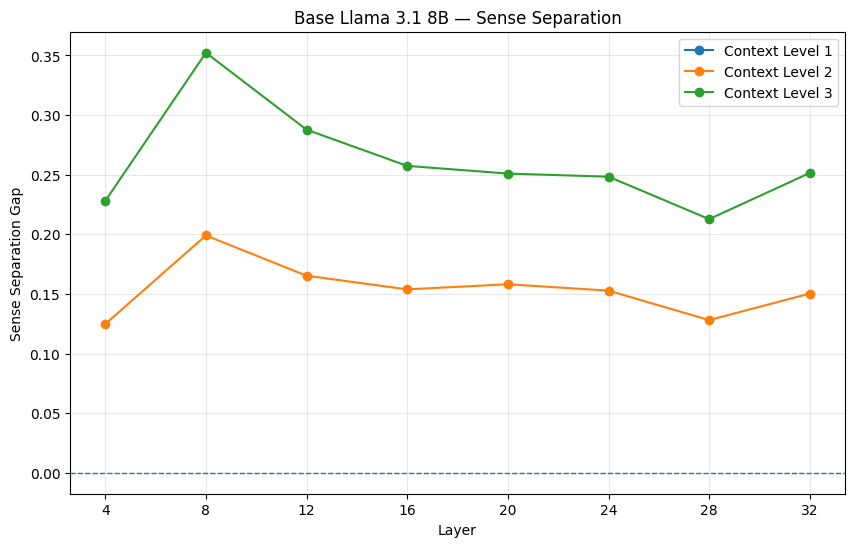

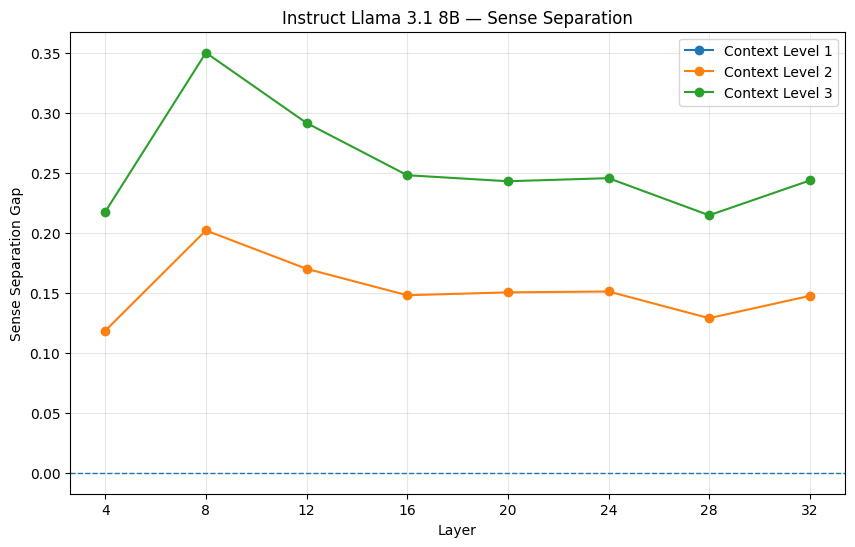

In [ ]:
import matplotlib.pyplot as plt

# Average distance gap across words
plot_df = (
    gap_df
    .groupby(["model", "context_level", "layer"])["distance_gap"]
    .mean()
    .reset_index()
)

# Plot Base and Instruct separately
for model in ["base", "instruct"]:

    model_df = plot_df[
        plot_df["model"] == model
    ]

    plt.figure(figsize=(10, 6))

    for context_level in [1, 2, 3]:

        context_df = model_df[
            model_df["context_level"] == context_level
        ]

        plt.plot(
            context_df["layer"],
            context_df["distance_gap"],
            marker="o",
            label=f"Context Level {context_level}"
        )

    plt.xlabel("Layer")
    plt.ylabel("Sense Separation Gap")
    plt.title(
        f"{model.capitalize()} Llama 3.1 8B — Sense Separation"
    )

    plt.xticks(TARGET_LAYERS)
    plt.axhline(0, linestyle="--", linewidth=1)

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
import pandas as pd


def calculate_rs(df):

    results = []

    for (word, sense, context_level, layer), group in df.groupby(
        ["word", "sense", "context_level", "layer"]
    ):

        base = group[group["model"] == "base"]
        instruct = group[group["model"] == "instruct"]

        if len(base) == 0 or len(instruct) == 0:
            continue

        # Sort by row_id so corresponding stimuli are aligned
        base = base.sort_values("row_id")
        instruct = instruct.sort_values("row_id")

        base_vectors = np.vstack(base["embedding"].values)
        instruct_vectors = np.vstack(instruct["embedding"].values)

        # Same stimulus: Base representation vs Instruct representation
        distances = np.diag(
            cosine_distances(
                base_vectors,
                instruct_vectors
            )
        )

        # Normalize cosine distance [0,2] -> [0,1]
        rs = np.mean(distances) / 2.0

        results.append({
            "word": word,
            "sense": sense,
            "context_level": context_level,
            "layer": layer,
            "RS": rs
        })

    return pd.DataFrame(results)


rs_df = calculate_rs(all_embeddings)

print("✅ Corrected Representational Shift calculated!")
print("Shape:", rs_df.shape)

display(rs_df.head(20))

✅ Corrected Representational Shift calculated!
Shape: (480, 5)


,word,sense,context_level,layer,RS
0,band,material_strip,1,4,0.011936
1,band,material_strip,1,8,0.010725
2,band,material_strip,1,12,0.012315
3,band,material_strip,1,16,0.008494
4,band,material_strip,1,20,0.009440
5,band,material_strip,1,24,0.009633
6,band,material_strip,1,28,0.010802
7,band,material_strip,1,32,0.021620
8,band,material_strip,2,4,0.016256
9,band,material_strip,2,8,0.027829


In [ ]:
def spread(vecs):
    """
    Mean Euclidean distance of usage vectors
    from their sense centroid.
    """
    centroid = vecs.mean(axis=0, keepdims=True)
    return np.linalg.norm(vecs - centroid, axis=1).mean()


def get_vecs(df, model, word, sense, context_level, layer):

    subset = df[
        (df["model"] == model) &
        (df["word"] == word) &
        (df["sense"] == sense) &
        (df["context_level"] == context_level) &
        (df["layer"] == layer)
    ]

    if len(subset) == 0:
        return None

    return np.vstack(subset["embedding"].values)


def delta(a, b):
    """
    Normalized difference.
    """
    denominator = a + b

    if denominator == 0:
        return 0.0

    return (a - b) / denominator


def sharpening_ratio_per_sense(
    df,
    model,
    word,
    sense,
    layer
):

    level2 = get_vecs(
        df,
        model,
        word,
        sense,
        2,
        layer
    )

    level3 = get_vecs(
        df,
        model,
        word,
        sense,
        3,
        layer
    )

    if level2 is None or level3 is None:
        return np.nan

    spread_level2 = spread(level2)
    spread_level3 = spread(level3)

    return delta(
        spread_level2,
        spread_level3
    )


def calculate_psd(df):

    results = []

    sense_map = {
        "yard": ("outdoor_area", "length_unit"),
        "tank": ("container", "military_vehicle"),
        "staple": ("routine_item", "wire_fastener"),
        "chest": ("body_part", "storage_box"),
        "trunk": ("tree_trunk", "car_compartment"),
        "temple": ("religious_building", "forehead"),
        "band": ("musical_group", "material_strip"),
        "tissue": ("biological_tissue", "paper_tissue"),
        "seal": ("marine_animal", "wax_stamp"),
        "racket": ("sports_equipment", "loud_noise")
    }

    for word, (dominant, subordinate) in sense_map.items():

        for layer in TARGET_LAYERS:

            ps_values = {}

            for model in ["base", "instruct"]:

                dominant_ps = sharpening_ratio_per_sense(
                    df,
                    model,
                    word,
                    dominant,
                    layer
                )

                subordinate_ps = sharpening_ratio_per_sense(
                    df,
                    model,
                    word,
                    subordinate,
                    layer
                )

                ps_values[model] = np.nanmean([
                    dominant_ps,
                    subordinate_ps
                ])

            base_ps = ps_values["base"]
            instruct_ps = ps_values["instruct"]

            if np.isnan(base_ps) or np.isnan(instruct_ps):
                psd = np.nan
            else:
                # Divide by 2 to preserve SRI's [-1,1] bound
                psd = (
                    instruct_ps - base_ps
                ) / 2.0

            results.append({
                "word": word,
                "layer": layer,
                "PS_base": base_ps,
                "PS_instruct": instruct_ps,
                "PSD": psd
            })

    return pd.DataFrame(results)


psd_df = calculate_psd(all_embeddings)

print("✅ Prototype Sharpening Differential calculated!")
print("Shape:", psd_df.shape)

display(psd_df.head(20))

✅ Prototype Sharpening Differential calculated!
Shape: (80, 5)


,word,layer,PS_base,PS_instruct,PSD
0,yard,4,0.105527,0.101602,-0.001963
1,yard,8,0.047391,0.044655,-0.001368
2,yard,12,0.016442,0.018824,0.001191
3,yard,16,0.035955,0.036151,0.000098
4,yard,20,0.051356,0.042960,-0.004198
5,yard,24,0.086699,0.081908,-0.002396
6,yard,28,0.089825,0.083171,-0.003327
7,yard,32,0.143420,0.137721,-0.002850
8,tank,4,-0.087984,-0.090267,-0.001142
9,tank,8,-0.072106,-0.063861,0.004122


In [ ]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# 1. Calculate Separability Ratio (SR)
# --------------------------------------------------

si_work = gap_df.copy()

si_work["SR"] = (
    si_work["different_sense_distance"]
    /
    (
        si_work["different_sense_distance"]
        + si_work["same_sense_distance"]
    )
)

# --------------------------------------------------
# 2. Compare Instruct vs Base
# --------------------------------------------------

sr_pivot = si_work.pivot_table(
    index=["word", "context_level", "layer"],
    columns="model",
    values="SR"
).reset_index()

# Make sure both models exist
print("Models found:", sr_pivot.columns.tolist())

# --------------------------------------------------
# 3. Instruct - Base improvement
# --------------------------------------------------

sr_pivot["SI_context"] = (
    sr_pivot["instruct"]
    - sr_pivot["base"]
)

# --------------------------------------------------
# 4. Average over the 3 context levels
# --------------------------------------------------

si_df = (
    sr_pivot
    .groupby(["word", "layer"])["SI_context"]
    .mean()
    .reset_index()
    .rename(columns={"SI_context": "SI"})
)

print("✅ Separability Improvement calculated!")
print("Shape:", si_df.shape)

display(si_df.head(20))

Models found: ['word', 'context_level', 'layer', 'base', 'instruct']
✅ Separability Improvement calculated!
Shape: (80, 3)


,word,layer,SI
0,band,4,0.006192
1,band,8,0.003884
2,band,12,0.007274
3,band,16,0.020266
4,band,20,0.024610
5,band,24,0.020832
6,band,28,0.019222
7,band,32,0.007866
8,chest,4,0.012682
9,chest,8,0.017209


In [ ]:
# Aggregate RS across both senses and all 3 context levels

rs_agg_df = (
    rs_df
    .groupby(["word", "layer"])["RS"]
    .mean()
    .reset_index()
)

print("✅ RS aggregated!")
print("Shape:", rs_agg_df.shape)

display(rs_agg_df.head(20))

✅ RS aggregated!
Shape: (80, 3)


,word,layer,RS
0,band,4,0.013736
1,band,8,0.017578
2,band,12,0.022096
3,band,16,0.018857
4,band,20,0.021785
5,band,24,0.020061
6,band,28,0.019604
7,band,32,0.033444
8,chest,4,0.013086
9,chest,8,0.017819


In [ ]:
# ---------------------------------------------
# Merge SI, RS and PSD
# ---------------------------------------------

sri_df = (
    si_df
    .merge(
        rs_agg_df,
        on=["word", "layer"],
        how="inner"
    )
    .merge(
        psd_df[["word", "layer", "PSD"]],
        on=["word", "layer"],
        how="inner"
    )
)

# ---------------------------------------------
# Calculate SRI
# ---------------------------------------------

sri_df["SRI"] = (
    sri_df["SI"]
    + sri_df["RS"]
    + sri_df["PSD"]
) / 3.0

# ---------------------------------------------
# Check result
# ---------------------------------------------

print("✅ SRI calculated!")
print("Shape:", sri_df.shape)

display(sri_df.head(20))

✅ SRI calculated!
Shape: (80, 6)


,word,layer,SI,RS,PSD,SRI
0,band,4,0.006192,0.013736,0.002971,0.007633
1,band,8,0.003884,0.017578,-0.001749,0.006571
2,band,12,0.007274,0.022096,0.011277,0.013549
3,band,16,0.020266,0.018857,0.017102,0.018742
4,band,20,0.024610,0.021785,0.024350,0.023582
5,band,24,0.020832,0.020061,0.027136,0.022676
6,band,28,0.019222,0.019604,0.027145,0.021990
7,band,32,0.007866,0.033444,0.027418,0.022909
8,chest,4,0.012682,0.013086,0.013663,0.013144
9,chest,8,0.017209,0.017819,0.006297,0.013775


In [ ]:
print("Minimum SRI:", sri_df["SRI"].min())
print("Maximum SRI:", sri_df["SRI"].max())

print("\nMissing values:")
print(sri_df.isna().sum())

Minimum SRI: 0.001573034223386005
Maximum SRI: 0.02980582576203239

Missing values:
word     0
layer    0
SI       0
RS       0
PSD      0
SRI      0
dtype: int64


In [ ]:
import pickle

with open("/content/sri_results.pkl", "wb") as f:
    pickle.dump(sri_df, f)

print("✅ SRI results saved!")
print("File: /content/sri_results.pkl")

✅ SRI results saved!
File: /content/sri_results.pkl


**Tables** **and** **Figures**

In [ ]:
# Average sense distances across words and layers
# for each model and context level

distance_plot = (
    gap_df
    .groupby(
        ["model", "context_level"]
    )[
        [
            "same_sense_distance",
            "different_sense_distance"
        ]
    ]
    .mean()
    .reset_index()
)

display(distance_plot)

,model,context_level,same_sense_distance,different_sense_distance
0,base,1,NaN,0.000000
1,base,2,0.342844,0.496843
2,base,3,0.333878,0.594987
3,instruct,1,NaN,0.000000
4,instruct,2,0.292296,0.444355
5,instruct,3,0.277525,0.534383


In [ ]:
# =============================================
# TABLE 1 — Word-level SRI summary
# =============================================

word_summary = (
    sri_df
    .groupby("word")
    .agg(
        Mean_SRI=("SRI", "mean"),
        SD_SRI=("SRI", "std"),
        Min_SRI=("SRI", "min"),
        Max_SRI=("SRI", "max")
    )
    .sort_values("Mean_SRI", ascending=False)
    .reset_index()
)

# Round for presentation
word_summary_display = word_summary.copy()

for col in ["Mean_SRI", "SD_SRI", "Min_SRI", "Max_SRI"]:
    word_summary_display[col] = word_summary_display[col].round(4)

display(word_summary_display)

,word,Mean_SRI,SD_SRI,Min_SRI,Max_SRI
0,racket,0.0199,0.0092,0.0069,0.0298
1,band,0.0172,0.0070,0.0066,0.0236
2,chest,0.0165,0.0025,0.0131,0.0199
3,seal,0.0159,0.0043,0.0059,0.0196
4,tank,0.0137,0.0048,0.0047,0.0209
5,temple,0.0124,0.0041,0.0045,0.0170
6,yard,0.0113,0.0020,0.0082,0.0144
7,tissue,0.0107,0.0038,0.0040,0.0158
8,trunk,0.0093,0.0060,0.0016,0.0222
9,staple,0.0082,0.0028,0.0018,0.0109


In [ ]:
# =============================================
# TABLE 2 — Layer-wise SRI summary
# =============================================

layer_summary = (
    sri_df
    .groupby("layer")
    .agg(
        Mean_SRI=("SRI", "mean"),
        SD_SRI=("SRI", "std"),
        Min_SRI=("SRI", "min"),
        Max_SRI=("SRI", "max")
    )
    .reset_index()
)

layer_summary_display = layer_summary.copy()

for col in ["Mean_SRI", "SD_SRI", "Min_SRI", "Max_SRI"]:
    layer_summary_display[col] = layer_summary_display[col].round(4)

display(layer_summary_display)

,layer,Mean_SRI,SD_SRI,Min_SRI,Max_SRI
0,4,0.0058,0.0034,0.0016,0.0131
1,8,0.0103,0.0033,0.0049,0.0163
2,12,0.0123,0.0028,0.0073,0.0161
3,16,0.0150,0.0032,0.0091,0.0187
4,20,0.0171,0.0056,0.0088,0.0263
5,24,0.0154,0.0066,0.0094,0.0298
6,28,0.0145,0.0067,0.0081,0.0293
7,32,0.0176,0.0062,0.0074,0.0265


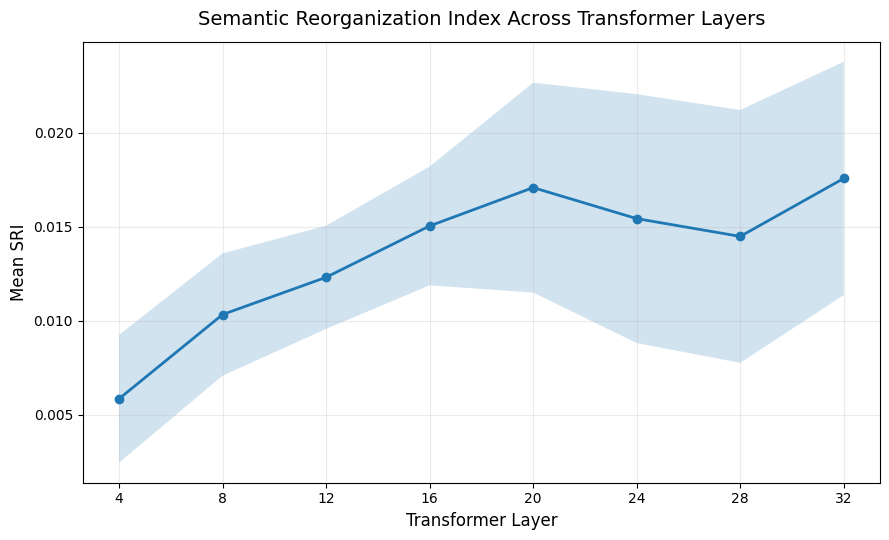

In [ ]:
# =============================================
# FIGURE 1 — Publication version
# =============================================

plt.figure(figsize=(9, 5.5))

plt.plot(
    sri_layer["layer"],
    sri_layer["mean"],
    marker="o",
    linewidth=2
)

plt.fill_between(
    sri_layer["layer"],
    sri_layer["mean"] - sri_layer["std"],
    sri_layer["mean"] + sri_layer["std"],
    alpha=0.2
)

plt.xlabel("Transformer Layer", fontsize=12)
plt.ylabel("Mean SRI", fontsize=12)

plt.title(
    "Semantic Reorganization Index Across Transformer Layers",
    fontsize=14,
    pad=12
)

plt.xticks(TARGET_LAYERS)

plt.grid(
    True,
    alpha=0.25
)

plt.tight_layout()

# Save high-resolution versions
plt.savefig(
    "/content/figure1_sri_layers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "/content/figure1_sri_layers.pdf",
    bbox_inches="tight"
)

plt.show()

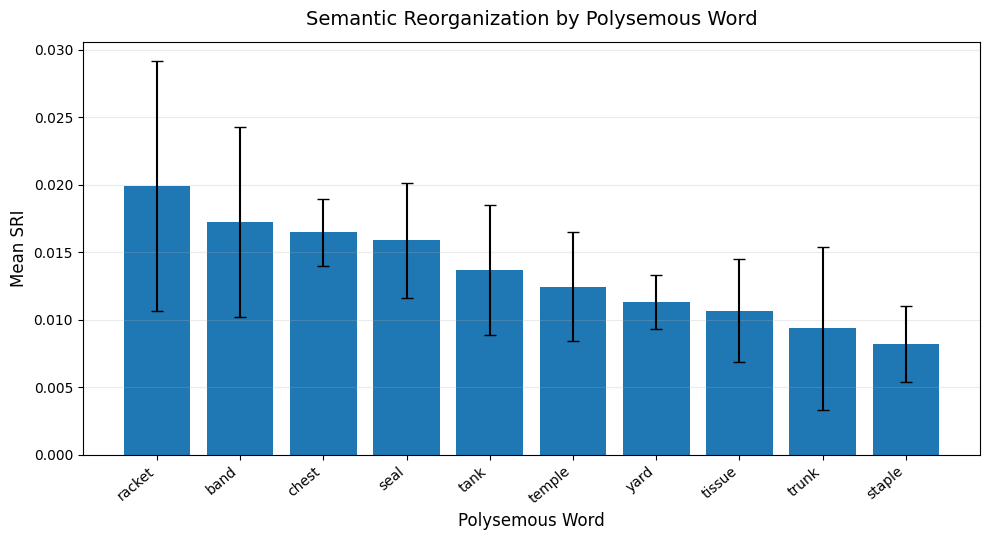

In [ ]:
# =============================================
# FIGURE 2 — SRI by polysemous word
# =============================================

plt.figure(figsize=(10, 5.5))

plt.bar(
    sri_word["word"],
    sri_word["mean"],
    yerr=sri_word["std"],
    capsize=4
)

plt.xlabel("Polysemous Word", fontsize=12)
plt.ylabel("Mean SRI", fontsize=12)

plt.title(
    "Semantic Reorganization by Polysemous Word",
    fontsize=14,
    pad=12
)

plt.xticks(
    rotation=40,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "/content/figure2_sri_words.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "/content/figure2_sri_words.pdf",
    bbox_inches="tight"
)

plt.show()

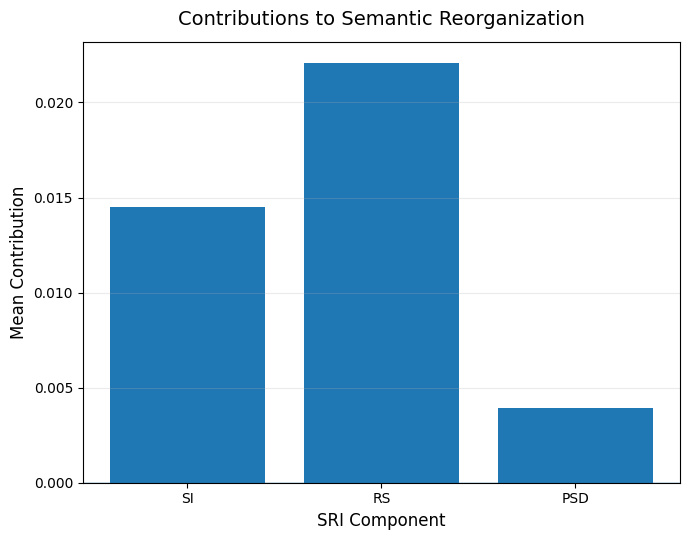

In [ ]:
# =============================================
# FIGURE 3 — SRI components
# =============================================

plt.figure(figsize=(7, 5.5))

plt.bar(
    component_means.keys(),
    component_means.values()
)

plt.xlabel("SRI Component", fontsize=12)
plt.ylabel("Mean Contribution", fontsize=12)

plt.title(
    "Contributions to Semantic Reorganization",
    fontsize=14,
    pad=12
)

plt.axhline(
    0,
    linewidth=1
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "/content/figure3_sri_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "/content/figure3_sri_components.pdf",
    bbox_inches="tight"
)

plt.show()

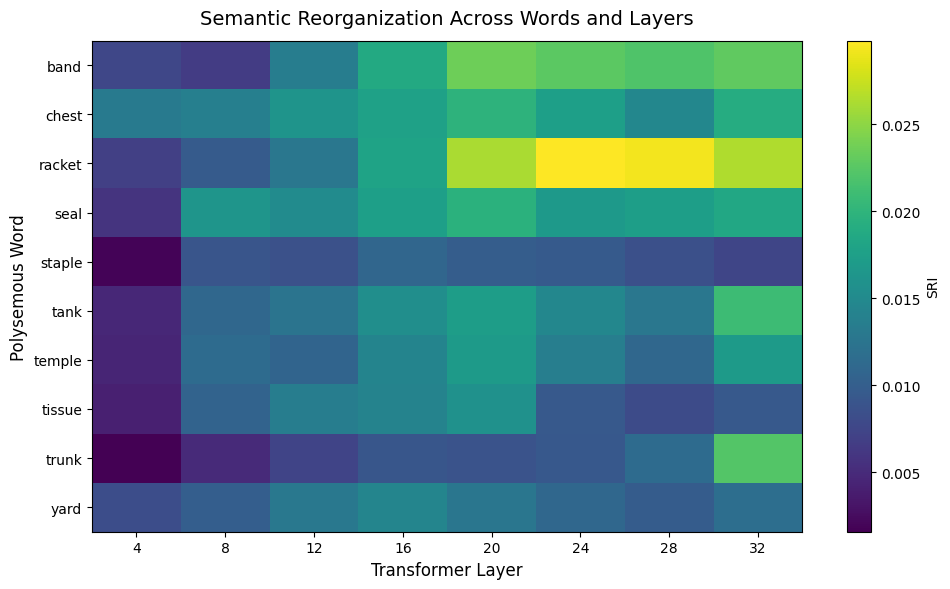

In [ ]:
# =============================================
# FIGURE 4 — SRI heatmap
# =============================================

sri_heatmap = sri_df.pivot(
    index="word",
    columns="layer",
    values="SRI"
)

plt.figure(figsize=(10, 6))

plt.imshow(
    sri_heatmap.values,
    aspect="auto"
)

plt.colorbar(
    label="SRI"
)

plt.xticks(
    range(len(sri_heatmap.columns)),
    sri_heatmap.columns
)

plt.yticks(
    range(len(sri_heatmap.index)),
    sri_heatmap.index
)

plt.xlabel("Transformer Layer", fontsize=12)
plt.ylabel("Polysemous Word", fontsize=12)

plt.title(
    "Semantic Reorganization Across Words and Layers",
    fontsize=14,
    pad=12
)

plt.tight_layout()

plt.savefig(
    "/content/figure4_sri_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "/content/figure4_sri_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()

**Statistical** **Summary**

In [ ]:
# =============================================
# STATISTICAL SUMMARY
# =============================================

print("SRI descriptive statistics")
print("=" * 50)

print(f"Overall mean: {sri_df['SRI'].mean():.6f}")
print(f"Overall SD:   {sri_df['SRI'].std():.6f}")
print(f"Overall min:  {sri_df['SRI'].min():.6f}")
print(f"Overall max:  {sri_df['SRI'].max():.6f}")

SRI descriptive statistics
Overall mean: 0.013516
Overall SD:   0.006014
Overall min:  0.001573
Overall max:  0.029806


**Master** **Results**

In [ ]:
# ============================================================
# CORRECTED COMPONENT-LEVEL STATISTICAL ANALYSIS
# Aggregate across layers first, then compare SI / RS / PSD
# ============================================================

from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Aggregate each component across the 8 layers for each word
# ------------------------------------------------------------

component_by_word = (
    sri_df
    .groupby("word")[["SI", "RS", "PSD"]]
    .mean()
    .reset_index()
)

print("Component values aggregated across layers:")
display(component_by_word.round(6))

# ------------------------------------------------------------
# 2. Friedman omnibus test
# ------------------------------------------------------------

friedman_components = friedmanchisquare(
    component_by_word["SI"],
    component_by_word["RS"],
    component_by_word["PSD"]
)

print("\nFriedman test: SI vs RS vs PSD")
print("=" * 55)
print(f"Statistic: {friedman_components.statistic:.6f}")
print(f"p-value:   {friedman_components.pvalue:.12e}")

# ------------------------------------------------------------
# 3. Pairwise Wilcoxon signed-rank tests
# ------------------------------------------------------------

component_pairs = [
    ("SI", "RS"),
    ("SI", "PSD"),
    ("RS", "PSD")
]

component_posthoc = []

for a, b in component_pairs:

    stat, p = wilcoxon(
        component_by_word[a],
        component_by_word[b],
        alternative="two-sided"
    )

    component_posthoc.append({
        "comparison": f"{a} vs {b}",
        "W": stat,
        "p_raw": p
    })

component_posthoc_df = pd.DataFrame(component_posthoc)

# ------------------------------------------------------------
# 4. Holm correction for the 3 pairwise comparisons
# ------------------------------------------------------------

reject, p_holm, _, _ = multipletests(
    component_posthoc_df["p_raw"],
    method="holm"
)

component_posthoc_df["p_holm"] = p_holm
component_posthoc_df["significant"] = reject

print("\nPairwise Wilcoxon tests with Holm correction")
print("=" * 55)

display(
    component_posthoc_df.style.format({
        "W": "{:.3f}",
        "p_raw": "{:.6e}",
        "p_holm": "{:.6e}"
    })
)

Component values aggregated across layers:


,word,SI,RS,PSD
0,band,0.013768,0.020895,0.016956
1,chest,0.020044,0.021091,0.008322
2,racket,0.027792,0.030696,0.001218
3,seal,0.022538,0.021353,0.003784
4,staple,0.000360,0.020063,0.004204
5,tank,0.011577,0.018135,0.011303
6,temple,0.017120,0.020643,-0.000421
7,tissue,0.009861,0.020197,0.001916
8,trunk,0.009511,0.024509,-0.005972
9,yard,0.012538,0.023334,-0.001852



Friedman test: SI vs RS vs PSD
Statistic: 14.600000
p-value:   6.755387751938e-04

Pairwise Wilcoxon tests with Holm correction


,comparison,W,p_raw,p_holm,significant
0,SI vs RS,2.000,5.859375e-03,1.171875e-02,True
1,SI vs PSD,5.000,1.953125e-02,1.953125e-02,True
2,RS vs PSD,0.000,1.953125e-03,5.859375e-03,True


In [ ]:
# ============================================================
# COMPONENT DESCRIPTIVE STATISTICS
# ============================================================

component_summary = pd.DataFrame({
    "Mean": component_by_word[["SI", "RS", "PSD"]].mean(),
    "Median": component_by_word[["SI", "RS", "PSD"]].median(),
    "SD": component_by_word[["SI", "RS", "PSD"]].std(),
    "Min": component_by_word[["SI", "RS", "PSD"]].min(),
    "Max": component_by_word[["SI", "RS", "PSD"]].max()
})

print("Component descriptive statistics")
print("=" * 55)

display(component_summary.round(6))

Component descriptive statistics


,Mean,Median,SD,Min,Max
SI,0.014511,0.013153,0.007733,0.000360,0.027792
RS,0.022091,0.020993,0.003494,0.018135,0.030696
PSD,0.003946,0.002850,0.006710,-0.005972,0.016956


In [ ]:
# ============================================================
# FINAL LAYER-WISE STATISTICAL ANALYSIS
# ============================================================

from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

# Create Word × Layer matrix
layer_matrix = (
    sri_df
    .pivot(
        index="word",
        columns="layer",
        values="SRI"
    )
    .sort_index(axis=1)
)

layers = list(layer_matrix.columns)

print("Layers:", layers)
print("Matrix shape:", layer_matrix.shape)

# ------------------------------------------------------------
# Friedman omnibus test
# ------------------------------------------------------------

layer_friedman = friedmanchisquare(
    *[layer_matrix[layer].values for layer in layers]
)

print("\nFriedman test across layers")
print("=" * 55)
print(f"Statistic: {layer_friedman.statistic:.6f}")
print(f"p-value:   {layer_friedman.pvalue:.12e}")

# ------------------------------------------------------------
# Pairwise Wilcoxon signed-rank tests
# ------------------------------------------------------------

layer_posthoc = []

for i in range(len(layers)):
    for j in range(i + 1, len(layers)):

        l1 = layers[i]
        l2 = layers[j]

        stat, p = wilcoxon(
            layer_matrix[l1],
            layer_matrix[l2],
            alternative="two-sided"
        )

        layer_posthoc.append({
            "layer_1": l1,
            "layer_2": l2,
            "W": stat,
            "p_raw": p
        })

layer_posthoc_df = pd.DataFrame(layer_posthoc)

# ------------------------------------------------------------
# Holm correction across all 28 pairwise comparisons
# ------------------------------------------------------------

reject, p_holm, _, _ = multipletests(
    layer_posthoc_df["p_raw"],
    method="holm"
)

layer_posthoc_df["p_holm"] = p_holm
layer_posthoc_df["significant"] = reject

print("\nAll layer pairwise comparisons:")
display(
    layer_posthoc_df.style.format({
        "W": "{:.3f}",
        "p_raw": "{:.6e}",
        "p_holm": "{:.6e}"
    })
)

print("\nSignificant comparisons after Holm correction:")
display(
    layer_posthoc_df[
        layer_posthoc_df["significant"]
    ].style.format({
        "W": "{:.3f}",
        "p_raw": "{:.6e}",
        "p_holm": "{:.6e}"
    })
)

Layers: [4, 8, 12, 16, 20, 24, 28, 32]
Matrix shape: (10, 8)

Friedman test across layers
Statistic: 43.300000
p-value:   2.918944746567e-07

All layer pairwise comparisons:


,layer_1,layer_2,W,p_raw,p_holm,significant
0,4,8,2.000,5.859375e-03,1.054688e-01,False
1,4,12,0.000,1.953125e-03,5.468750e-02,False
2,4,16,0.000,1.953125e-03,5.468750e-02,False
3,4,20,0.000,1.953125e-03,5.468750e-02,False
4,4,24,0.000,1.953125e-03,5.468750e-02,False
5,4,28,0.000,1.953125e-03,5.468750e-02,False
6,4,32,0.000,1.953125e-03,5.468750e-02,False
7,8,12,6.000,2.734375e-02,4.101562e-01,False
8,8,16,0.000,1.953125e-03,5.468750e-02,False
9,8,20,0.000,1.953125e-03,5.468750e-02,False



Significant comparisons after Holm correction:


,layer_1,layer_2,W,p_raw,p_holm,significant


In [ ]:
# ============================================================
# MEAN SRI BY LAYER
# ============================================================

layer_summary = (
    sri_df
    .groupby("layer")["SRI"]
    .agg(["mean", "median", "std", "min", "max"])
    .reset_index()
)

print("SRI by layer")
print("=" * 55)

display(layer_summary.round(6))

SRI by layer


,layer,mean,median,std,min,max
0,4,0.005842,0.005282,0.003400,0.001573,0.013144
1,8,0.010329,0.010310,0.003256,0.004893,0.016312
2,12,0.012313,0.012836,0.002750,0.007341,0.016142
3,16,0.015047,0.014992,0.003163,0.009079,0.018742
4,20,0.017089,0.017167,0.005588,0.008827,0.026274
5,24,0.015438,0.014157,0.006628,0.009380,0.029806
6,28,0.014491,0.012092,0.006732,0.008073,0.029293
7,32,0.017579,0.018799,0.006214,0.007424,0.026494


In [ ]:
# ============================================================
# SAVE FINAL STATISTICAL RESULTS
# ============================================================

import os
import pickle

RESULTS_DIR = "/content/drive/MyDrive/AT1_Term_Paper/Results"

os.makedirs(RESULTS_DIR, exist_ok=True)

final_statistics = {
    "sri_df": sri_df,
    "component_by_word": component_by_word,
    "component_summary": component_summary,
    "component_friedman": {
        "statistic": friedman_components.statistic,
        "p_value": friedman_components.pvalue
    },
    "component_posthoc": component_posthoc_df,
    "layer_matrix": layer_matrix,
    "layer_summary": layer_summary,
    "layer_friedman": {
        "statistic": layer_friedman.statistic,
        "p_value": layer_friedman.pvalue
    },
    "layer_posthoc": layer_posthoc_df
}

final_path = os.path.join(
    RESULTS_DIR,
    "final_statistical_results.pkl"
)

with open(final_path, "wb") as f:
    pickle.dump(final_statistics, f)

print("✅ FINAL STATISTICAL RESULTS SAVED!")
print("File:", final_path)
print("Size:", round(os.path.getsize(final_path) / 1024, 2), "KB")

✅ FINAL STATISTICAL RESULTS SAVED!
File: /content/drive/MyDrive/AT1_Term_Paper/Results/final_statistical_results.pkl
Size: 8.48 KB
